## PRÁCTICA 3: Aprendizaje por refuerzo

##### Importamos el entorno

In [34]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

env = gym.make("Pendulum-v1", render_mode="rgb_array", g=9.81)  # default g=10.0

##### Mostramos el entorno

In [35]:
obs, _ = env.reset()

print("Observación inicial:", obs)


Observación inicial: [-0.20515668  0.9787291   0.86125505]


##### Discretizamos las acciones

In [42]:
NUM_ACCIONES = 20
acciones = np.linspace(-2, 2, NUM_ACCIONES)  # 20 acciones discretas

##### Discretizamos los estados

In [43]:
NUM_INTERVALOS = 20

cos_intervalos = np.linspace(-1, 1, NUM_INTERVALOS)
sin_intervalos = np.linspace(-1, 1, NUM_INTERVALOS)
vel_intervalos = np.linspace(-8, 8, NUM_INTERVALOS)

In [44]:
def discretizar_estado(obs):
    cos_t, sin_t, vel = obs

    # la función np.digitize(valor, bins) asigna un valor a su intervalo correspondiente
    i = np.digitize(cos_t, cos_intervalos) - 1
    j = np.digitize(sin_t, sin_intervalos) - 1
    k = np.digitize(vel, vel_intervalos) - 1

    i = np.clip(i, 0, NUM_INTERVALOS-1)
    j = np.clip(j, 0, NUM_INTERVALOS-1)
    k = np.clip(k, 0, NUM_INTERVALOS-1)

    return (i, j, k)

In [64]:
obs, _ = env.reset()

estado_discreto = discretizar_estado(obs)

print("Estado continuo:", obs)
print("Estado discreto:", estado_discreto)

Estado continuo: [-0.57334125 -0.8193167   0.8907234 ]
Estado discreto: (np.int64(4), np.int64(1), np.int64(10))


## Montecarlo

In [68]:
def muestrea_politica(estado, politica):
    cos_bin, sin_bin, vel_bin = estado

    probs = politica[cos_bin, sin_bin, vel_bin]

    np.testing.assert_almost_equal(np.sum(probs), 1.0, err_msg='La política para un estado siempre debe sumar 1')

    accion_idx = np.random.choice(NUM_ACCIONES, p=probs)

    return accion_idx

##### Simulamos episodio

In [200]:
def simula_episodio(politica: np.ndarray, imprime: bool = False):

    obs, _ = env.reset()
    estado_actual = discretizar_estado(obs)

    completado = False
    contador = 0
    retorno = 0
    recorrido = []

    max_steps = 200  # Pendulum no termina solo

    while not completado and contador < max_steps:

        accion_idx = muestrea_politica(estado_actual, politica)
        accion = np.array([acciones[accion_idx]])
        obs, recompensa, terminated, truncated, info = env.step(accion)
        recorrido.append((estado_actual, accion_idx, recompensa))

        nuevo_estado = discretizar_estado(obs)
        retorno += recompensa
        contador += 1

        estado_actual = nuevo_estado
        completado = terminated or truncated or (contador >= max_steps)

        if imprime:
            print("Paso:", contador)
            print("Acción idx:", accion_idx)
            print("Acción real:", accion)
            print("Estado:", estado_actual)
            print("Recompensa:", recompensa)

    return retorno, contador, recorrido

#### Montecarlo (ϵ-soft on-policy)

In [214]:
def mc_control(num_pasos:int=50000, EPSILON:float=0.4, GAMMA:float = 1) -> np.ndarray:

    qsa = np.zeros((NUM_INTERVALOS, NUM_INTERVALOS, NUM_INTERVALOS, NUM_ACCIONES))
    politica = np.zeros((NUM_INTERVALOS, NUM_INTERVALOS, NUM_INTERVALOS, NUM_ACCIONES))
    # Partimos de la política aleatoria
    politica[:] = 1.0 / NUM_ACCIONES

    retornos = [[[ [ [] for _ in range(NUM_ACCIONES)]
                   for _ in range(qsa.shape[2])]
                   for _ in range(qsa.shape[1])]
                   for _ in range(qsa.shape[0])]

    media_movil = []
    retornos_medios = []

    for episodio in range(num_pasos):
        ep_retorno, ep_num_pasos, ep_recorrido = simula_episodio(politica)
        
        # guardar retorno del episodio
        media_movil.append(ep_retorno)
        # mantener ventana deslizante
        if len(media_movil) > 1000:
            media_movil.pop(0)
        # guardar media
        retornos_medios.append(np.mean(media_movil))

        g = 0
        estados_acciones_vistos = []
        for (i, j, k), accion, recompensa in reversed(ep_recorrido):
            g = g * GAMMA + recompensa

            if (i,j,k,accion) not in estados_acciones_vistos:
                estados_acciones_vistos.append((i,j,k,accion))

                retornos[i][j][k][accion].append(g)

                qsa[i,j,k,accion] = np.mean(retornos[i][j][k][accion])

                # política ε-soft
                mejor_accion = np.argmax(qsa[i,j,k,:])

                for a in range(NUM_ACCIONES):
                    if a == mejor_accion:
                        politica[i,j,k,a] = 1 - EPSILON + EPSILON / NUM_ACCIONES
                    else:
                        politica[i,j,k,a] = EPSILON / NUM_ACCIONES
        EPSILON = max(0.001, EPSILON * 0.9999)
    return politica, retornos_medios


# Calculamos la política usando un epsilon de 0.4 para garantizar la exploración
politica_montecarlo_es, retornos_medios_mc = mc_control(EPSILON=0.4)

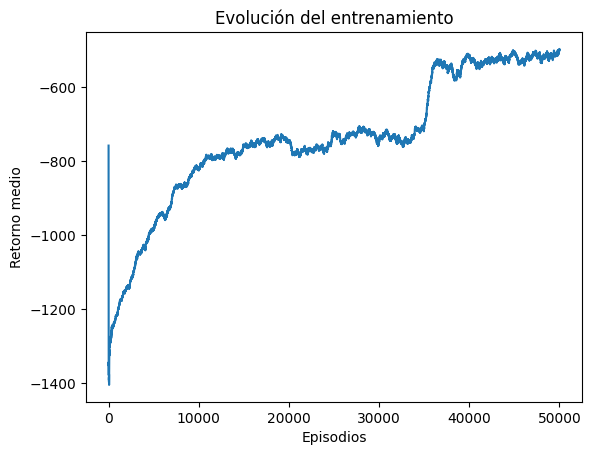

-563.0332313979561


In [216]:
plt.plot(retornos_medios_mc)
plt.xlabel("Episodios")
plt.ylabel("Retorno medio")
plt.title("Evolución del entrenamiento")
plt.show()
print(comprueba_politica_determinista(politica_montecarlo_es))

#### SARSA

In [109]:
def get_accion_epsilon_greedy(q_valores_acciones:np.ndarray, epsilon:float):
    if np.random.random()<epsilon:
        return np.random.randint(0, NUM_ACCIONES) # Obtenemos una acción aleatoria con probabilidad epsilon
    return np.argmax(q_valores_acciones)


In [111]:
def sarsa(num_episodios:int = 50000, ALPHA:float = 0.1, EPSILON:float = 0.25, DECAY:float = 0.9999, GAMMA:float = 0.9, imprime:bool = False) -> np.ndarray:
    q_valores = np.zeros((NUM_INTERVALOS, NUM_INTERVALOS, NUM_INTERVALOS, NUM_ACCIONES))
    retornos = []
    media_movil = []
    cnt = 0
    while cnt < num_episodios:
        cnt += 1
        retorno = 0
        num_pasos = 0
        completado = False
        observacion, _ = env.reset()
        env.max_steps = 300
        estado_actual = discretizar_estado(observacion)
        accion_escogida = get_accion_epsilon_greedy(q_valores[*estado_actual, :], EPSILON * DECAY ** cnt)
        while not completado:
            valores_acciones = q_valores[*estado_actual, :]
            observacion, recompensa, terminated, truncated, info = env.step(np.array([acciones[accion_escogida]]))
            nuevo_estado = discretizar_estado(observacion)
            nuevos_valores_acciones = q_valores[*nuevo_estado, :]
            nueva_accion = get_accion_epsilon_greedy(nuevos_valores_acciones, EPSILON * DECAY ** cnt)
            retorno += recompensa
            num_pasos += 1
            completado = terminated or truncated
            valor_actual = valores_acciones[accion_escogida]
            nuevo_valor = nuevos_valores_acciones[nueva_accion]
            q_valores[*estado_actual, accion_escogida] = valor_actual + ALPHA * (recompensa + GAMMA * nuevo_valor - valor_actual)

            estado_actual = nuevo_estado
            accion_escogida = nueva_accion
        media_movil.append(retorno)
        if len(media_movil)==1001:
            media_movil.pop(0)
            retornos.append(np.mean(media_movil))
        if imprime: print(f'Terminado episodio {cnt} con retorno {retorno} en {num_pasos} pasos')
    return q_valores, retornos

q_valores_sarsa, retornos_medios_sarsa = sarsa(imprime=True)

Terminado episodio 1 con retorno -1473.7052285484374 en 200 pasos
Terminado episodio 2 con retorno -1471.2619021098094 en 200 pasos
Terminado episodio 3 con retorno -1433.2976033996358 en 200 pasos
Terminado episodio 4 con retorno -1671.860366978554 en 200 pasos
Terminado episodio 5 con retorno -1353.6521967332042 en 200 pasos
Terminado episodio 6 con retorno -1377.6661714952538 en 200 pasos
Terminado episodio 7 con retorno -1312.1318338697772 en 200 pasos
Terminado episodio 8 con retorno -1261.15950209114 en 200 pasos
Terminado episodio 9 con retorno -1026.8480745900663 en 200 pasos
Terminado episodio 10 con retorno -1322.2759833890623 en 200 pasos
Terminado episodio 11 con retorno -1666.4982829472267 en 200 pasos
Terminado episodio 12 con retorno -1237.3908624048145 en 200 pasos
Terminado episodio 13 con retorno -1204.999136146162 en 200 pasos
Terminado episodio 14 con retorno -1146.300088065705 en 200 pasos
Terminado episodio 15 con retorno -1167.8683823380234 en 200 pasos
Terminado

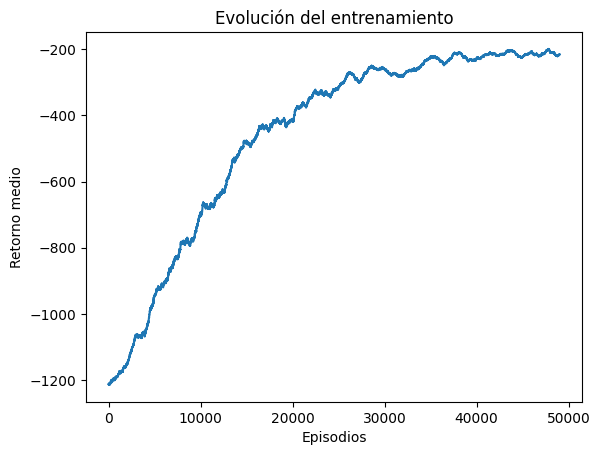

In [112]:
plt.plot(retornos_medios_sarsa)
plt.xlabel("Episodios")
plt.ylabel("Retorno medio")
plt.title("Evolución del entrenamiento")
plt.show()

#### Qlearning

In [150]:
def qlearning(num_episodios:int = 50000, ALPHA:float = 0.1, EPSILON:float = 0.25, DECAY:float = 0.9999, GAMMA:float = 0.9, imprime:bool = False) -> np.ndarray:
    q_valores = np.zeros((NUM_INTERVALOS, NUM_INTERVALOS, NUM_INTERVALOS, NUM_ACCIONES))
    retornos = []
    media_movil = []
    cnt = 0
    while cnt < num_episodios:
        cnt += 1
        retorno = 0
        num_pasos = 0
        completado = False
        observacion, _ = env.reset()
        env.max_steps = 200
        estado_actual = discretizar_estado(observacion)
        while not completado:
            accion_escogida = get_accion_epsilon_greedy(q_valores[*estado_actual, :], EPSILON * DECAY ** cnt)
            valores_acciones = q_valores[*estado_actual, :]
            observacion, recompensa, terminated, truncated, info = env.step(np.array([acciones[accion_escogida]]))
            nuevo_estado = discretizar_estado(observacion)
            nuevos_valores_acciones = q_valores[*nuevo_estado, :]
            retorno += recompensa
            num_pasos += 1
            completado = terminated or truncated
            valor_actual = valores_acciones[accion_escogida]
            q_valores[*estado_actual, accion_escogida] = valor_actual + ALPHA * (recompensa + GAMMA * np.max(nuevos_valores_acciones) - valor_actual)
            estado_actual = nuevo_estado

        media_movil.append(retorno)
        if len(media_movil)==1001:
            media_movil.pop(0)
            retornos.append(np.mean(media_movil))
        if imprime: print(f'Terminado episodio {cnt} con retorno {retorno} en {num_pasos} pasos')
    return q_valores, retornos
qlearning_valores, retornos_medios_qlearning = qlearning(imprime=True)

Terminado episodio 1 con retorno -1282.033282033755 en 200 pasos
Terminado episodio 2 con retorno -1305.4733061990032 en 200 pasos
Terminado episodio 3 con retorno -1437.7805872151341 en 200 pasos
Terminado episodio 4 con retorno -1510.244280252877 en 200 pasos
Terminado episodio 5 con retorno -1230.3987432566787 en 200 pasos
Terminado episodio 6 con retorno -1572.1538477339216 en 200 pasos
Terminado episodio 7 con retorno -1109.0086125675082 en 200 pasos
Terminado episodio 8 con retorno -1380.011504500068 en 200 pasos
Terminado episodio 9 con retorno -1185.2672169041616 en 200 pasos
Terminado episodio 10 con retorno -1502.6015676488412 en 200 pasos
Terminado episodio 11 con retorno -1298.6801915920255 en 200 pasos
Terminado episodio 12 con retorno -1581.4722653700048 en 200 pasos
Terminado episodio 13 con retorno -1297.7519195492187 en 200 pasos
Terminado episodio 14 con retorno -1150.6865765402872 en 200 pasos
Terminado episodio 15 con retorno -1586.112010422746 en 200 pasos
Terminad

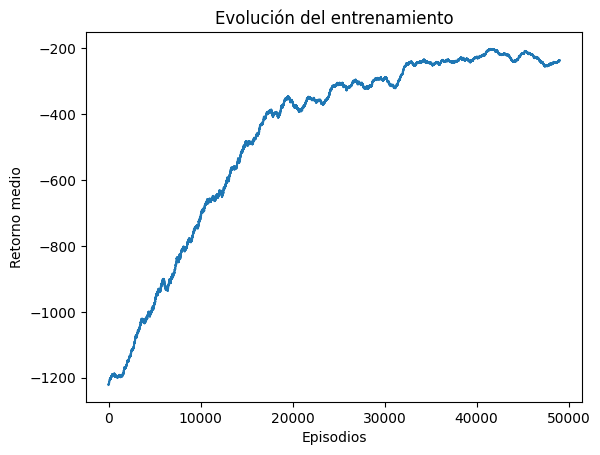

In [153]:
plt.plot(retornos_medios_qlearning)
plt.xlabel("Episodios")
plt.ylabel("Retorno medio")
plt.title("Evolución del entrenamiento")
plt.show()

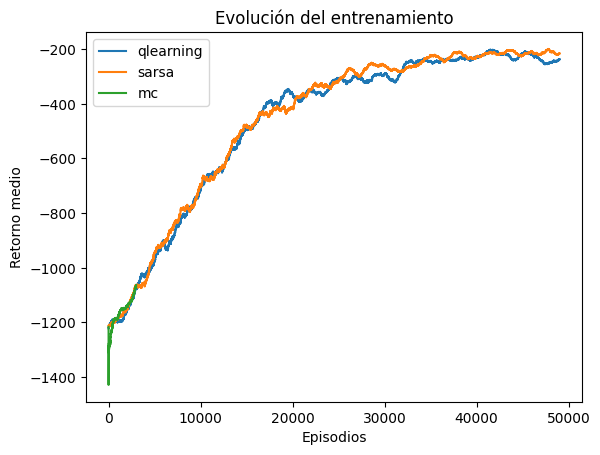

In [193]:
plt.plot(retornos_medios_qlearning, label="qlearning")
plt.plot(retornos_medios_sarsa, label="sarsa")
plt.plot(retornos_medios_mc, label="mc")
plt.xlabel("Episodios")
plt.ylabel("Retorno medio")
plt.title("Evolución del entrenamiento")
plt.legend()
plt.show()

#### Comprobar politica

In [143]:
def comprueba_politica_determinista(politica:np.ndarray, num_episodios:int = 1000, ruido:bool = False) -> None:
    env.reset()
    retornos = []
    cnt = 0
    while cnt < num_episodios:
        cnt += 1
        retorno = 0
        num_pasos = 0
        completado = False
        env.reset()
        env.max_steps = 200
        estado_actual = discretizar_estado(obs)
        while not completado:
            accion_escogida = get_accion_epsilon_greedy(politica[*estado_actual, :], 0)
            accion_escogida = np.random.choice((0, -1)) if ruido and (np.random.random() < 0.05) else accion_escogida
            observacion, recompensa, terminated, truncated, info = env.step(np.array([acciones[accion_escogida]]))
            nuevo_estado = discretizar_estado(observacion)
            retorno += recompensa
            num_pasos += 1
            completado = terminated or truncated
            estado_actual = nuevo_estado
        retornos.append(retorno)
    return np.mean(retornos)
comprueba_politica_determinista(qlearning_valores)

np.float64(-396.51552794566715)

#### Búsqueda de hiperparámetros

In [148]:
from itertools import product
param_grid = {"num_episodios": [2 * 1e4], "ALPHA": [0.1, 0.15], "EPSILON": [0.25], "DECAY": [0.99995, 0.9999], "GAMMA": [0.9]}
resultados = []
for config in product(*param_grid.values()):
    for algo in (sarsa, qlearning):
        print(algo.__name__, config)
        val, graf = algo(*config)
        comp = comprueba_politica_determinista(val)
        resultados.append((algo.__name__, config, val, graf, comp))

sarsa (20000.0, 0.1, 0.25, 0.99995, 0.9)
qlearning (20000.0, 0.1, 0.25, 0.99995, 0.9)
sarsa (20000.0, 0.1, 0.25, 0.9999, 0.9)
qlearning (20000.0, 0.1, 0.25, 0.9999, 0.9)
sarsa (20000.0, 0.15, 0.25, 0.99995, 0.9)
qlearning (20000.0, 0.15, 0.25, 0.99995, 0.9)
sarsa (20000.0, 0.15, 0.25, 0.9999, 0.9)
qlearning (20000.0, 0.15, 0.25, 0.9999, 0.9)


In [152]:
encabezados = ["algo", "config", "comp"]

filas = [
    (algo, str(config), str(comp))
    for algo, config, _, _, comp in resultados
]

anchos = [len(h) for h in encabezados]

for fila in filas:
    for i, valor in enumerate(fila):
        anchos[i] = max(anchos[i], len(valor))

print(
    " | ".join(
        encabezados[i].ljust(anchos[i])
        for i in range(len(encabezados))))

print("-+-".join("-" * a for a in anchos))

for fila in filas:
    print(
        " | ".join(
            fila[i].ljust(anchos[i])
            for i in range(len(encabezados))))

algo      | config                              | comp               
----------+-------------------------------------+--------------------
sarsa     | (20000.0, 0.1, 0.25, 0.99995, 0.9)  | -339.9680695223477 
qlearning | (20000.0, 0.1, 0.25, 0.99995, 0.9)  | -383.85151853342705
sarsa     | (20000.0, 0.1, 0.25, 0.9999, 0.9)   | -522.7805151749724 
qlearning | (20000.0, 0.1, 0.25, 0.9999, 0.9)   | -508.54698656600044
sarsa     | (20000.0, 0.15, 0.25, 0.99995, 0.9) | -358.0596983219652 
qlearning | (20000.0, 0.15, 0.25, 0.99995, 0.9) | -279.67304431048547
sarsa     | (20000.0, 0.15, 0.25, 0.9999, 0.9)  | -250.3029322044642 
qlearning | (20000.0, 0.15, 0.25, 0.9999, 0.9)  | -282.24619499415735


#### Entrenamientos Finales

In [198]:
f_val_mc, f_plot_mc = mc_control(30000)
# f_val_sarsa, f_plot_sarsa = sarsa(50000, 0.15, 0.25, 0.9999, 0.9)
# f_val_qlearning, f_plot_qlearning = qlearning(50000, 0.15, 0.25, 0.99995, 0.9)


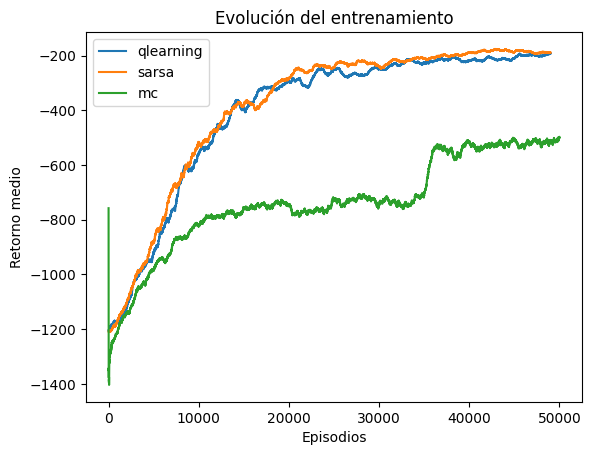

In [217]:
plt.plot(f_plot_qlearning, label="qlearning")
plt.plot(f_plot_sarsa, label="sarsa")
plt.plot(retornos_medios_mc, label="mc")
plt.xlabel("Episodios")
plt.ylabel("Retorno medio")
plt.title("Evolución del entrenamiento")
plt.legend()
plt.show()

In [197]:
print("sarsa", "Sin ruido", comprueba_politica_determinista(f_val_sarsa))
print("qlearning", "Sin ruido", comprueba_politica_determinista(f_val_qlearning))
print("mc", "Sin ruido", comprueba_politica_determinista(f_val_mc))
print("sarsa", "Con ruido", comprueba_politica_determinista(f_val_sarsa, ruido=True))
print("qlearning", "Con ruido", comprueba_politica_determinista(f_val_qlearning, ruido=True))
print("mc", "Con ruido", comprueba_politica_determinista(f_val_mc, ruido=True))

sarsa Sin ruido -184.4244639656216
qlearning Sin ruido -191.5672912095421
mc Sin ruido -615.6852741668763
sarsa Con ruido -219.8500261211429
qlearning Con ruido -206.274873705708
mc Con ruido -676.670276209327
